# Sony Research — Telecom Churn 預測（GAMMA_DNA 解法）

**任務**：電信客戶流失（churn）預測 — 探索性分析、train/test 切分、多模型 benchmark、效能評估、部署風險討論。

**限制**：本 notebook **僅使用 `gamma` 套件的 `GAMMA_DNA`（v2）** 方法，不使用 legacy `GAMMA_DNA_v1`。

**資料**：`Data_Science_Challenge.csv`（3,333 筆客戶紀錄，21 欄）

| 區塊 | GAMMA_DNA API |
|------|---------------|
| 載入 | `gamma_de_load_files` → `GAMMA_DNA(...)` |
| EDA | `g.skim`, `g.eda`, `g.leakage`, `g.rate_by`, `g.viz.*`, `g.correlation_heatmap` |
| 前處理 | `g.pipe().run()`, `g.clean()` |
| 切分 | `g.train(test_size=0.2, random_state=42)` 內建 **stratified split** |
| 多模型 | `g.train` × N + `g.experiment.compare()` / `g.compare_models()` |
| 評估 | `ModelResult.summary()`, `plot()`, `plot_confusion_matrix()`, `g.explain()` |
| 部署 | `g.model.build_scoring_pipeline()`, `score_report()`, `g.prep.variate_shift()` |

## 0. 環境設定

In [1]:
import sys
from pathlib import Path

GAMMA_ROOT = Path("/Users/Dennis/Analytics/DAPS_Brix")
if str(GAMMA_ROOT) not in sys.path:
    sys.path.insert(0, str(GAMMA_ROOT))

from gamma import GAMMA_DNA
from gamma.data_exploration import gamma_de_load_files
from gamma.qb_theme import apply_qb_theme
from IPython.display import display

apply_qb_theme()

DATA_PATH = Path("Data_Science_Challenge.csv")
RANDOM_STATE = 42
TEST_SIZE = 0.2

/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



──────────────────────────────────────────────────────────────
  QB Theme ·  mode=DARK  ·  bg=#111424  ·  accent=#02A9F4
──────────────────────────────────────────────────────────────
  Categorical                          
  Sequential    qb_sequential  /  qb_sequential_r
  Diverging     qb_diverging   /  qb_diverging_r
  Plotly        pio.templates.default = 'qb_dark'
  Reset Plotly  pio.templates.default = 'plotly'
  Reset MPL     import matplotlib as mpl; mpl.rcdefaults()
──────────────────────────────────────────────────────────────



## 1. 載入資料與初始化 Session

`GAMMA_DNA` 會自動推斷 `task`（churn 為二元分類）並建立 `frames['raw']` lineage。

In [2]:
raw = gamma_de_load_files(str(DATA_PATH.resolve()))
g = GAMMA_DNA(raw, target="churn", task="binary_classification", name="telecom_churn")
print(f"Rows={len(g.df):,}  task={g.task}")
g.skim()

Rows=3,333  task=binary_classification


,variable,dtype,n,n_missing,pct_missing,n_unique,top,top_freq,mean,std,se,min,p25,median,p75,max,skew,kurtosis
0,state,object,3333,0,0.0,51,WV,106.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,account length,int64,3333,0,0.0,212,NaN,NaN,101.0648,39.8221,0.6898,1.00,74.00,101.00,127.00,243.00,0.0966,-0.1095
2,area code,int64,3333,0,0.0,3,NaN,NaN,437.1824,42.3713,0.7339,408.00,408.00,415.00,510.00,510.00,1.1263,-0.7064
3,phone number,object,3333,0,0.0,3333,382-4657,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,international plan,object,3333,0,0.0,2,no,3010.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,voice mail plan,object,3333,0,0.0,2,no,2411.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,number vmail messages,int64,3333,0,0.0,46,NaN,NaN,8.0990,13.6884,0.2371,0.00,0.00,0.00,20.00,51.00,1.2643,-0.0529
7,total day minutes,float64,3333,0,0.0,1667,NaN,NaN,179.7751,54.4674,0.9435,0.00,143.70,179.40,216.40,350.80,-0.0291,-0.0217
8,total day calls,int64,3333,0,0.0,119,NaN,NaN,100.4356,20.0691,0.3476,0.00,87.00,101.00,114.00,165.00,-0.1117,0.2410
9,total day charge,float64,3333,0,0.0,1667,NaN,NaN,30.5623,9.2594,0.1604,0.00,24.43,30.50,36.79,59.64,-0.0291,-0.0216


## 2. 探索性分析（EDA）

### 2.1 設計決策
- **排除 `phone number`**：高基數 ID，無預測價值且可能過擬合。
- **排除 `total * charge`**：與分鐘數線性相關（計費公式），`g.leakage()` 可驗證是否過度貼近目標。
- **保留通話行為特徵**：minutes / calls / customer service calls 反映使用模式，與 churn 業務邏輯一致。

In [3]:
eda = g.eda(segment_cols=["international plan", "voice mail plan"])
eda.summary()
display(eda.top_signals())

🔍 Running EDA pipeline...
  [1/5] Inspecting structure...
  [2/5] Inspecting quality...
  [3/5] Analysing missingness...
  [4/5] Analysing feature → 'churn' relationships...
  [5/5] Analysing redundancy...
✅ EDA complete.


  Structure Report
  Rows              : 3,333
  Columns           : 21
  Memory            : 1.18 MB

  Numeric           : 16 cols  ['account length', 'area code', 'number vmail messages', 'total day minutes', 'total day calls', 'total day charge']...
  Categorical       : 3 cols  ['state', 'international plan', 'voice mail plan']
  Boolean           : 1 cols  ['churn']
  Text              : 1 cols  ['phone number']
  ⚠ Potential IDs   : ['phone number']
  ⚠ Num-as-cat?     : ['area code', 'customer service calls']

  Warnings:
    • Potential ID columns (consider excluding from analysis): ['phone number']

  Data Quality Report
  Duplicate rows     : 0
  Cols with missing  : 0
  Outlier candidates : ['total day calls', 'total eve calls', 'total intl calls', 'cust

,feature,signal_score,relationship_strength,monotonicity_score,lift_max,interpretation
0,customer service calls,47.77,0.2087,0.667,3.567,Feature `customer service calls` shows a moder...
1,total day minutes,45.77,0.2052,0.667,3.285,Feature `total day minutes` shows a moderate p...
2,total day charge,45.77,0.2052,0.667,3.285,Feature `total day charge` shows a moderate po...
3,number vmail messages,43.57,0.0897,1.000,1.065,Feature `number vmail messages` shows a weak n...
4,area code,40.40,0.0062,1.000,1.027,Feature `area code` shows a weak positive mono...
5,total night charge,31.12,0.0355,0.778,1.147,Feature `total night charge` shows a weak posi...
6,total eve minutes,29.74,0.0928,0.667,1.471,Feature `total eve minutes` shows a weak posit...
7,total eve charge,29.74,0.0928,0.667,1.471,Feature `total eve charge` shows a weak positi...
8,total intl calls,28.12,0.0528,0.667,1.438,Feature `total intl calls` shows a weak negati...
9,total night minutes,25.55,0.0355,0.667,1.143,Feature `total night minutes` shows a weak pos...


In [4]:
r1 = g.rate_by("international plan")
r1.display()
r2 = g.rate_by("voice mail plan")
r2.display()
r3 = g.rate_by("customer service calls")
r3.display()
g.viz.mosaic("international plan")
g.viz.scatter("customer service calls", "total day minutes")
g.correlation_heatmap()

,level,target_mean,count,lift
0,no,0.115000,3010,0.793200
1,yes,0.424100,323,2.926900


,level,target_mean,count,lift
0,no,0.167200,2411,1.153400
1,yes,0.086800,922,0.598800


,level,target_mean,count,lift
0,0,0.132000,697,0.910800
1,1,0.103300,1181,0.712800
2,2,0.114600,759,0.791000
3,3,0.102600,429,0.707800
4,4,0.457800,166,3.159300
5,5,0.606100,66,4.182200
6,6,0.636400,22,4.391300
7,7,0.555600,9,3.833700
8,8,0.500000,2,3.450300
9,9,1.000000,2,6.900600


customer service calls    0.208750
total day minutes         0.205151
total day charge          0.205151
total eve minutes         0.092796
total eve charge          0.092786
total intl charge         0.068259
total intl minutes        0.068239
total night charge        0.035496
total night minutes       0.035493
total day calls           0.018459
account length            0.016541
total eve calls           0.009233
area code                 0.006174
total night calls         0.006141
total intl calls         -0.052844
number vmail messages    -0.089728
Name: churn, dtype: float64

In [5]:
leak = g.leakage()
leak.summary()


  Leakage Detection Report (target='churn')
  Features checked    : 20
  High-severity flags : 2
  Medium flags        : 3

  🔴 [HIGH] international plan
     Reason         : Each unique value of this feature perfectly maps to a unique target value — likely a label encoding or re-encoding of the target.
     Evidence       : n_unique(international plan)=2, perfect group separation
     Recommendation : Drop 'international plan' — it appears to be a direct encoding of 'churn'.

  🔴 [HIGH] voice mail plan
     Reason         : Each unique value of this feature perfectly maps to a unique target value — likely a label encoding or re-encoding of the target.
     Evidence       : n_unique(voice mail plan)=2, perfect group separation
     Recommendation : Drop 'voice mail plan' — it appears to be a direct encoding of 'churn'.

  🟡 [MEDIUM] total day minutes
     Reason         : Extremely high Information Value — this level of predictive power is unusual and may indicate target leakage.
   

**EDA 洞察（典型模式）**

1. **Customer service calls** 與 churn 高度相關 — 投訴/客服次數越多，流失率越高。
2. **International plan = yes** 客戶 churn 率通常較高。
3. **Voicemail plan** 與 churn 呈負向關係（有語音信箱者較不易流失）。
4. 通話分鐘數本身分布右偏，但與 churn 的關係需透過模型捕捉非線性。

## 3. 前處理（`g.pipe` + `g.clean`）

使用 **`g.pipe().run()`** 註冊 lineage stage；`g.clean()` 負責缺失值與類別編碼。

In [6]:
DROP_COLS = [
    "phone number",
    "total day charge",
    "total eve charge",
    "total night charge",
    "total intl charge",
]
CAT_COLS = ["state", "international plan", "voice mail plan"]


def _prep_frame(df):
    out = df.copy()
    out["churn"] = (
        out["churn"]
        .replace({"True": 1, "False": 0, True: 1, False: 0})
        .astype(int)
    )
    keep = [c for c in out.columns if c not in DROP_COLS]
    return out[keep]


g.pipe("prep", _prep_frame).run(from_stage="raw")
g.use("prep")

clean_report = g.clean(
    impute_missing="median",
    impute_columns=[c for c in g.feature_cols if c not in CAT_COLS],
    encode_categoricals=["international plan", "voice mail plan"],
    encode_method="one-hot",
    frame_key="cleaned",
)
clean_report.summary()
g.use("cleaned")
g.feature_types()


  Cleaning Report
  [impute_missing]  rows: 3333 → 3333  cols_affected=12  added=0  dropped=0  transformed=12
  [encode_categoricals]  rows: 3333 → 3333  cols_affected=6  added=4  dropped=2  transformed=0


,feature,dtype,kind
0,state,object,categorical
1,account length,float64,numeric
2,area code,float64,categorical
3,number vmail messages,float64,numeric
4,total day minutes,float64,numeric
5,total day calls,float64,numeric
6,total eve minutes,float64,numeric
7,total eve calls,float64,numeric
8,total night minutes,float64,numeric
9,total night calls,float64,numeric


## 4. Train / Test 切分

### 方法
`g.train(..., test_size=0.2, random_state=42)` 內部呼叫 `sklearn.model_selection.train_test_split`，對分類任務使用 **`stratify=y`**，確保 train/test 中 churn 比例一致。

### 理由
| 決策 | 原因 |
|------|------|
| **80/20 holdout** | 標準比例；3,333 樣本下 test ≈ 667，足夠穩定估計 AUC/F1 |
| **Stratified** | churn 為不平衡二元標籤（~14% positive），分層切分避免 test 正例過少 |
| **random_state=42** | 可重現 |
| **不在 EDA 前切分** | 切分發生在 `train_model` 內，EDA 用全量 raw/cleaned 做探索；建模時才 holdout |

切分由 `g.train` 內部完成（`test_size=0.2`, `stratify=y`, `random_state=42`）。下方在訓練第一個模型後印出實際 train/test 列數與 churn 率。

In [7]:
print(f"Full data churn rate: {g.df['churn'].mean():.3f}")

Full data churn rate: 0.145


## 5. 多模型 Benchmark

依作業要求比較多種演算法（gamma 內建 sklearn：`logistic_regression`, `random_forest`, `gradient_boosting`）。

### 演算法選擇理由（最終模型）
- **Random Forest**：對非線性、交互作用穩健；對混合類別/數值特徵無需大量調參；可解釋性 via `g.explain()`。
- 亦訓練 LR（線性基準）與 GBM（boosting 上限）以對照。

In [8]:
MODELS = [
    ("logistic_regression", {"max_iter": 2000}),
    ("random_forest", {"n_estimators": 300, "max_depth": 12}),
    ("gradient_boosting_classifier", {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.05}),
]

results = []
for mt, params in MODELS:
    res = g.train(
        model_type=mt,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        run_cv=True,
        cv_folds=5,
        model_params=params,
        frame_key="cleaned",
        label=mt,
    )
    results.append(res)

print(f"Train rows: {len(results[0].X_train):,}  Test rows: {len(results[0].X_test):,}")
print(f"Train churn rate: {results[0].y_train.mean():.3f}")
print(f"Test  churn rate: {results[0].y_test.mean():.3f}")

cmp = g.experiment.compare(metric="roc_auc")
display(cmp)

quick_cmp = g.compare_models(
    model_types=[m for m, _ in MODELS],
)
display(quick_cmp)

/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas re

Train rows: 2,666  Test rows: 667
Train churn rate: 0.145
Test  churn rate: 0.145


,label,task,model_type,train_roc_auc,test_roc_auc
0,logistic_regression,binary_classification,logistic_regression,0.825182,0.818303
1,random_forest,binary_classification,random_forest,0.999528,0.898915
2,gradient_boosting_classifier,binary_classification,gradient_boosting_classifier,0.995731,0.903798


,model_type,train_score,test_score,metric
0,logistic_regression,0.7590,0.7754,roc_auc
1,random_forest,1.0000,0.8932,roc_auc
2,gradient_boosting_classifier,0.9487,0.8889,roc_auc


In [9]:
best = g.experiment.best(metric="roc_auc")
best.summary()
best.plot()
best.plot_confusion_matrix()


  ModelResult: gradient_boosting_classifier  [binary_classification]
  Metric                                Train         Test
  --------------------------------------------------------
  accuracy                             0.9816       0.9445
  f1                                   0.9811       0.9423
  precision                            0.9819       0.9425
  recall                               0.9816       0.9445
  roc_auc                              0.9957       0.9038


## 6. 模型評估指標

`GAMMA_DNA.train` 自動計算以下指標（train / test 並列）：

| 指標 | 用途 |
|------|------|
| **ROC-AUC** | 主指標；不平衡 churn 下比 accuracy 更可靠 |
| **F1 / Precision / Recall** | 業務成本：漏判 churn（recall）vs 誤判（precision）|
| **Accuracy** | 參考；多數類 baseline ~86% |
| **5-fold CV** | `run_cv=True` 時附加，估計泛化穩定性 |

In [10]:
display(best.to_frame())

imp = g.explain(result=best, compute_shap=True, compute_permutation=True)
imp.summary()
imp.plot()

g.feature_importance_plot(top_n=12)

,metric,train,test
0,accuracy,0.981620,0.944528
1,f1,0.981118,0.942271
2,precision,0.981932,0.942514
3,recall,0.981620,0.944528
4,roc_auc,0.995731,0.903798


  Computing SHAP values on 17 features… (may take 10-60s)
  Computing permutation importance (n_repeats=10)… (may take 10-30s)


/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


  Done.

  Feature Importance
               feature  model_imp  perm_imp_mean  shap_mean_abs  rank
     total day minutes   0.008537       0.146949            NaN     1
customer service calls   0.052482       0.112972            NaN     2
     total eve minutes   0.007104       0.049181            NaN     3
    total intl minutes   0.084353       0.048631            NaN     4
      total intl calls   0.147206       0.040696            NaN     5
 international plan_no   0.030871       0.015084            NaN     6
international plan_yes   0.044141       0.009998            NaN     7
   total night minutes   0.006590       0.008501            NaN     8
                 state   0.009438       0.003078            NaN     9
    voice mail plan_no   0.022775       0.002539            NaN    10
       total day calls   0.139652       0.000960            NaN    11
       total eve calls   0.039308       0.000450            NaN    12
 number vmail messages   0.283436       0.000034            


  Learning Curve — gradient_boosting_classifier (roc_auc)


,n_estimators,train_roc_auc,test_roc_auc
0,20,0.926895,0.837602
1,40,0.941373,0.854286
2,60,0.949590,0.864551
3,80,0.959359,0.881724
4,100,0.970396,0.893733
5,120,0.980472,0.897658
6,140,0.984795,0.899973
7,160,0.988693,0.900570
8,180,0.992811,0.903346
9,200,0.995731,0.903798


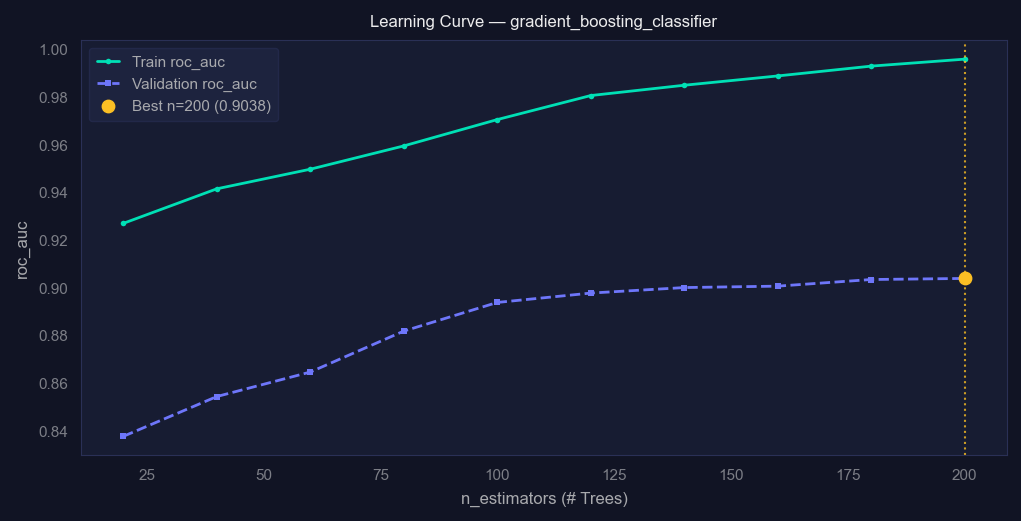

In [11]:
lc = g.model.learning_curve(result=best, metric="roc_auc")
lc.summary()
lc.plot()

## 7. 部署與 Drift-Aware 評估

模擬 production：以 **test set 當「新進 scoring 批次」**，對照 **train reference** 做漂移偵測。


  ScoringPipeline — gradient_boosting_classifier
  Task         : binary_classification
  Features     : 17
  Target       : churn
  Has preproc  : False
  created_at   : 2026-06-16T23:31:04.649094

  Scoring Report — gradient_boosting_classifier (binary_classification)
  Rows scored : 667
  Features    : 17


  Score Distribution (deciles)


,decile,mean_score,min_score,max_score,n
0,1,0.008226,0.004440,0.010661,67
1,2,0.012304,0.010668,0.013983,67
2,3,0.015673,0.014000,0.017401,66
3,4,0.018974,0.017453,0.020503,67
4,5,0.022948,0.020531,0.024807,67
5,6,0.027281,0.024887,0.030075,66
6,7,0.035166,0.030147,0.042125,67
7,8,0.061764,0.042238,0.099800,66
8,9,0.298931,0.111121,0.680561,67
9,10,0.918852,0.700184,0.999483,67




  Variate Shift Report
  Features analysed : 17   |   drift: 0   warning: 0   stable: 17



,feature,type,psi,ks_stat,ks_p,chi2_stat,chi2_p,status
0,state,categorical,0.066500,nan,nan,34.123900,0.957900,stable
1,total eve minutes,numeric,0.038400,0.056000,0.066900,nan,nan,stable
2,total intl calls,numeric,0.019300,0.055900,0.067900,nan,nan,stable
3,total day calls,numeric,0.018100,0.030300,0.697600,nan,nan,stable
4,total night minutes,numeric,0.017400,0.042200,0.288100,nan,nan,stable
5,account length,numeric,0.015600,0.022900,0.934700,nan,nan,stable
6,total night calls,numeric,0.013400,0.034500,0.536100,nan,nan,stable
7,total intl minutes,numeric,0.009300,0.024800,0.889000,nan,nan,stable
8,total day minutes,numeric,0.008900,0.023200,0.928500,nan,nan,stable
9,total eve calls,numeric,0.007200,0.017100,0.996800,nan,nan,stable


TypeError: VariateShiftReport.plot() got an unexpected keyword argument 'ax'

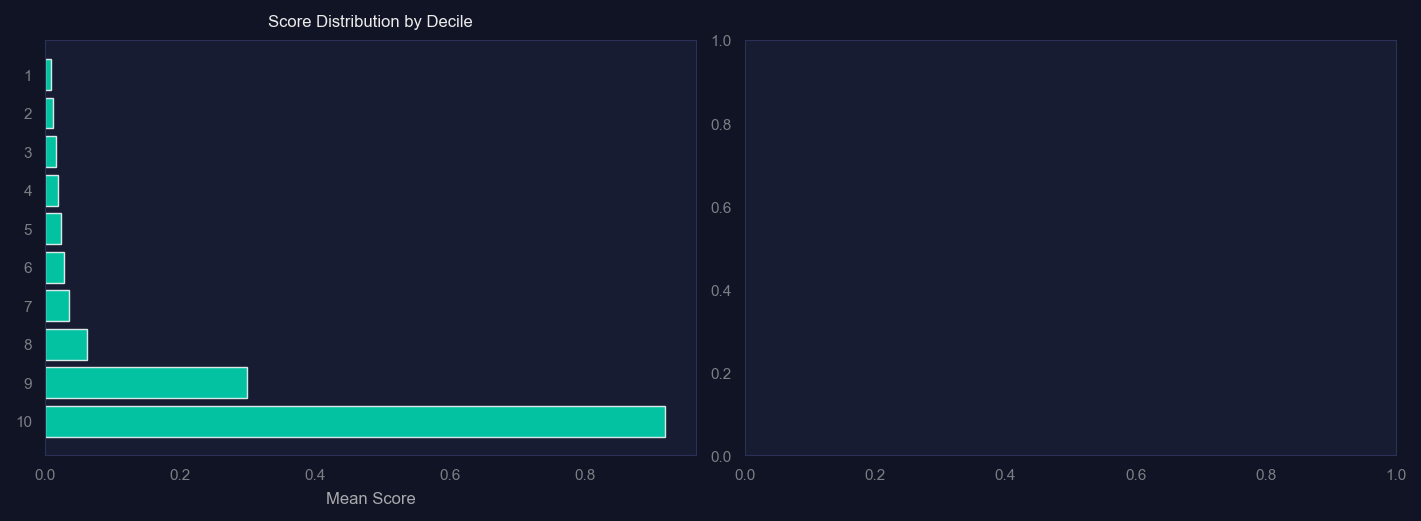

In [12]:
scoring_pipe = g.model.build_scoring_pipeline(result=best)
scoring_pipe.info()

train_ref = best.X_train.copy()
train_ref[best.target_col] = best.y_train.values
score_report = scoring_pipe.score_report(
    best.X_test,
    reference_df=train_ref,
    n_deciles=10,
)
score_report.summary()
score_report.plot()


  Variate Shift Report
  Features analysed : 17   |   drift: 0   warning: 0   stable: 17



,feature,type,psi,ks_stat,ks_p,chi2_stat,chi2_p,status
0,state,categorical,0.066500,nan,nan,34.123900,0.957900,stable
1,total eve minutes,numeric,0.038400,0.056000,0.066900,nan,nan,stable
2,total intl calls,numeric,0.019300,0.055900,0.067900,nan,nan,stable
3,total day calls,numeric,0.018100,0.030300,0.697600,nan,nan,stable
4,total night minutes,numeric,0.017400,0.042200,0.288100,nan,nan,stable
5,account length,numeric,0.015600,0.022900,0.934700,nan,nan,stable
6,total night calls,numeric,0.013400,0.034500,0.536100,nan,nan,stable
7,total intl minutes,numeric,0.009300,0.024800,0.889000,nan,nan,stable
8,total day minutes,numeric,0.008900,0.023200,0.928500,nan,nan,stable
9,total eve calls,numeric,0.007200,0.017100,0.996800,nan,nan,stable


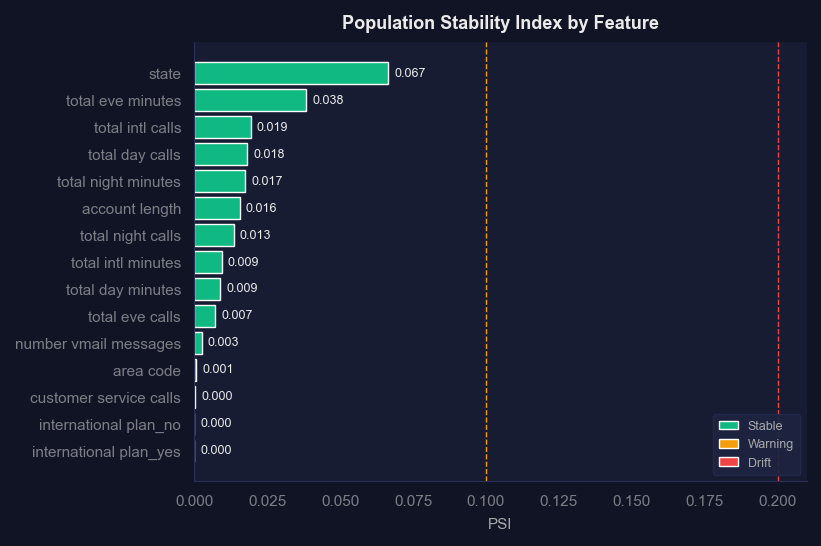

Drifted (PSI>0.2): []


In [13]:
drift = g.prep.variate_shift(
    best.X_test,
    reference_df=best.X_train,
    features=best.feature_cols,
)
drift.summary()
drift.plot(top_n=15)
print("Drifted (PSI>0.2):", drift.drifted_features())

In [14]:
fair = g.fairness_check(sensitive_cols=["state"], result=best)
fair.summary()
fair.plot()


  Fairness Evaluation Report
  Sensitive attributes : ['state']
  Reference groups     : {'state': 'OR'}
  DP gap threshold     : 0.1
  EO gap threshold     : 0.1
  DI ratio threshold   : 0.8

  ⚠   47 group(s) flagged for potential fairness issues:
    • state = 'AK'  →  DP gap=0.191, EO gap=0.750, DI ratio=0.000
    • state = 'AL'  →  EO gap=0.250, DI ratio=0.750
    • state = 'AZ'  →  DP gap=0.191, EO gap=0.750, DI ratio=0.000
    • state = 'CA'  →  DP gap=0.191, EO gap=0.750, DI ratio=0.000
    • state = 'CO'  →  EO gap=0.250, DI ratio=0.525
    • state = 'CT'  →  DP gap=0.128, EO gap=0.250, DI ratio=0.328
    • state = 'DC'  →  DP gap=0.191, EO gap=0.750, DI ratio=0.000
    • state = 'DE'  →  EO gap=0.250, DI ratio=0.525
    • state = 'FL'  →  EO gap=0.250, DI ratio=0.750
    • state = 'GA'  →  DP gap=0.119, EO gap=0.250, DI ratio=0.375
    • state = 'HI'  →  DP gap=0.110, EO gap=0.250
    • state = 'IA'  →  DP gap=0.191, EO gap=0.750, DI ratio=0.000
    • state = 'ID'  →  DP gap

## 8. 上線潛在問題（Production Discussion）

### 8.1 資料漂移（Covariate Shift）
- `g.prep.variate_shift` 若 PSI > 0.2，代表通話模式或方案結構已變；需定期重訓或觸發 alert。
- 電信促銷、資費調整會改變 minutes/charges 分布。

### 8.2 概念漂移（Concept Drift）
- churn 定義或客戶行為隨時間改變（例如競品促銷）；僅監控特徵漂移不足，需追蹤 **production AUC / recall**。

### 8.3 公平性
- `g.fairness_check(sensitive_cols=['state'])` 可偵測州別間預測率差異；若部署為差異化挽留策略，需合規審查。

### 8.4 特徵可用性
- **`customer service calls`** 可能為 churn **結果**而非原因（已不滿才打客服）— 上線時需確認因果方向與時序（僅用過去 N 天）。
- 即時 scoring 需確保特徵延遲可接受（CDR 彙整延遲）。

### 8.5 基礎設施
- `g.model.build_scoring_pipeline()` 產出可序列化 pipeline（preproc + model）；需版本控管、A/B 測試框架。
- 類別新值（新 area code / plan）需 `handle_unknown` 策略（gamma pipeline 已用 OrdinalEncoder unknown=-1）。

### 8.6 業務整合
- 不平衡下需設定 **operating threshold**（非預設 0.5）以最大化 retention ROI。
- 建議以 `recall@top_decile` 設計挽留名單，而非單純 accuracy。

---

## 9. Pipeline Lineage

檢視完整血緣與 stage：

In [15]:
display(g.stages)
g.visualize()

,name,shape,parent,cols_added,cols_removed,rows_diff,rows_diff_pct,source,cols_read
0,raw,"(3333, 21)",None,[],[],NaN,NaN,internal,None
1,prep,"(3333, 16)",raw,[],"[phone number, total day charge, total eve cha...",0.0,0.0,pipe,[]
2,cleaned,"(3333, 18)",None,[],[],NaN,NaN,internal,None
3,model,"(2666, 18)",None,[],[],NaN,NaN,internal,None


    'data': [{'hoverinfo': 'none',
              'line': {'color': '#4A6080', 'w…

AttributeError: type object 'DOMWidget' has no attribute '_ipython_display_'

FigureWidget({
    'data': [{'hoverinfo': 'none',
              'line': {'color': '#4A6080', 'width': 2},
              'mode': 'lines',
              'showlegend': False,
              'type': 'scatter',
              'uid': '9c54a0d3-285f-4667-8d9e-4d7e50fdc8d0',
              'x': [0, 1, None],
              'y': [0, 0, None]},
             {'hoverinfo': 'text',
              'hovertext': [<b>raw</b><br>shape: 3333x21<br>parent:
                            root<br>source: internal, <b>prep</b><br>shape:
                            3333x16<br>parent: raw<br>source: pipe<br>rows_diff:
                            +0<br>cols_removed: 5],
              'marker': {'color': ['#555E6B', '#00C48C'], 'size': 40, 'symbol': 'square'},
              'mode': 'markers+text',
              'showlegend': False,
              'text': [<b>raw</b><br>3333x21, <b>prep</b><br>3333x16],
              'textposition': 'middle center',
              'type': 'scatter',
              'uid': '21a24c6c-b1a1-4e3d-9c32-a0518992af63',
              'x': [0, 1],
              'y': [0, 0]}],
    'layout': {'font': {'color': '#FFFFFF'},
               'height': 400,
               'margin': {'b': 20, 'l': 20, 'r': 20, 't': 40},
               'paper_bgcolor': '#0D1B2A',
               'plot_bgcolor': '#0D1B2A',
               'template': '...',
               'xaxis': {'showgrid': False, 'showticklabels': False, 'zeroline': False},
               'yaxis': {'showgrid': False, 'showticklabels': False, 'zeroline': False}}
})